In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from lifetimes import BetaGeoFitter, GammaGammaFitter
import yaml

# Load cấu hình từ file config.yaml
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [2]:
df = pd.read_csv('../data/interim/rfm_calibration.csv')
features = ['Recency', 'Frequency', 'Net_Sales']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features])

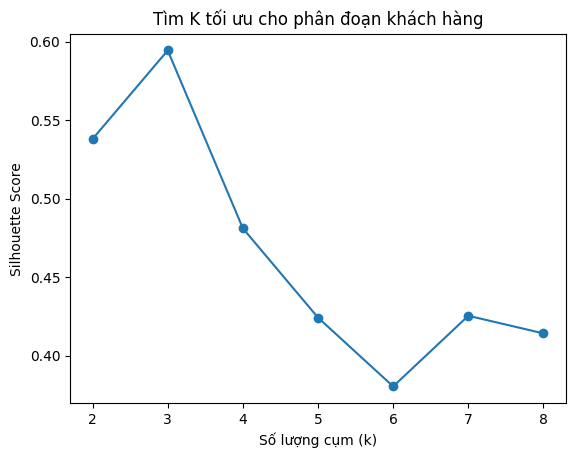

In [3]:
scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_scaled)
    scores.append(silhouette_score(df_scaled, labels))

plt.plot(range(2, 9), scores, marker='o')
plt.xlabel('Số lượng cụm (k)')
plt.ylabel('Silhouette Score')
plt.title('Tìm K tối ưu cho phân đoạn khách hàng')
plt.show()